Using device: cuda
Epoch 0, Loss: 5.2040
Epoch 300, Loss: 0.1087
Epoch 600, Loss: 0.0986
Epoch 900, Loss: 0.0983
Epoch 1200, Loss: 0.0983
Epoch 1500, Loss: 0.0983
Epoch 1800, Loss: 0.0984
Epoch 2100, Loss: 0.0983
Epoch 2400, Loss: 0.0983
Epoch 2700, Loss: 0.0983


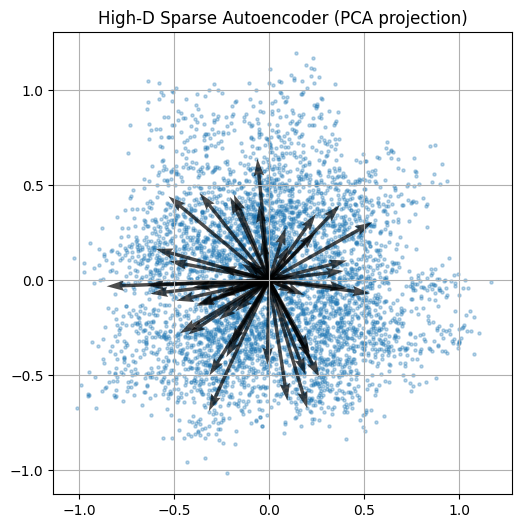

In [1]:
# pip install torch matplotlib scikit-learn if needed

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# -----------------------
# 0. Device
# -----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------
# 1. Generate high-dim sparse data
# -----------------------
def generate_sparse_data(n_points=5000, dim=10, n_active=3, noise=0.05):
    basis = np.eye(dim)

    data = []
    for _ in range(n_points):
        idx = np.random.choice(dim, n_active, replace=False)
        coeffs = np.random.uniform(0.5, 1.0, size=n_active)

        x = np.zeros(dim)
        for i, c in zip(idx, coeffs):
            x += c * basis[i]

        x += noise * np.random.randn(dim)
        data.append(x)

    return torch.tensor(np.array(data), dtype=torch.float32)

input_dim = 10
hidden_dim = 50

X = generate_sparse_data(dim=input_dim).to(device)

# -----------------------
# 2. Sparse Autoencoder
# -----------------------
class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.decoder = nn.Linear(hidden_dim, input_dim, bias=False)

    def forward(self, x):
        h = torch.relu(self.encoder(x))
        x_recon = self.decoder(h)
        return x_recon, h

    def normalize_decoder(self):
        with torch.no_grad():
            W = self.decoder.weight.data  # (input_dim, hidden_dim)
            W /= (W.norm(dim=0, keepdim=True) + 1e-8)

model = SparseAutoencoder(input_dim, hidden_dim).to(device)

# -----------------------
# 3. Training
# -----------------------
optimizer = optim.Adam(model.parameters(), lr=1e-3)
lambda_l1 = 0.1
epochs = 3000
batch_size = 256

for epoch in range(epochs):
    perm = torch.randperm(X.size(0))
    total_loss = 0

    for i in range(0, X.size(0), batch_size):
        batch = X[perm[i:i+batch_size]]

        optimizer.zero_grad()

        x_recon, h = model(batch)

        recon_loss = ((batch - x_recon) ** 2).mean()
        sparsity_loss = lambda_l1 * h.abs().mean()

        loss = recon_loss + sparsity_loss
        loss.backward()
        optimizer.step()

        model.normalize_decoder()
        total_loss += loss.item()

    if epoch % 300 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss:.4f}")

# -----------------------
# 4. PCA projection
# -----------------------
with torch.no_grad():
    X_np = X.cpu().numpy()
    W = model.decoder.weight.detach().cpu().numpy()  # (input_dim, hidden_dim)

# Fit PCA on data
pca = PCA(n_components=2)
X_proj = pca.fit_transform(X_np)

# Project dictionary vectors
W_proj = pca.transform(W.T)  # (hidden_dim, 2)

# -----------------------
# 5. Visualization
# -----------------------
plt.figure(figsize=(6,6))

# Data points
plt.scatter(X_proj[:,0], X_proj[:,1], s=5, alpha=0.3)

# Dictionary vectors
origin = np.zeros((W_proj.shape[0], 2))
plt.quiver(
    origin[:,0], origin[:,1],
    W_proj[:,0], W_proj[:,1],
    angles='xy', scale_units='xy', scale=1,
    alpha=0.7
)

plt.title("High-D Sparse Autoencoder (PCA projection)")
plt.gca().set_aspect('equal')
plt.grid(True)

plt.show()

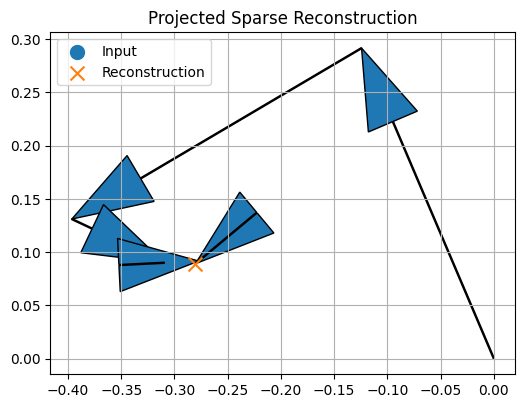

In [27]:
def visualize_projected_reconstruction(model, x, pca, k=3):
    model.eval()

    with torch.no_grad():
        x = x.unsqueeze(0).to(device)
        x_recon, h = model(x)

        h = h.squeeze().cpu().numpy()
        W = model.decoder.weight.detach().cpu().numpy()

        x_np = x.squeeze().cpu().numpy()

        topk = np.argsort(h)[-k:][::-1]

        # Project everything
        x_proj = pca.transform([x_np])[0]

        vectors = []
        for i in topk:
            vec = h[i] * W[:, i]
            vec_proj = pca.transform([vec])[0]
            vectors.append(vec_proj)

    # Plot
    plt.figure(figsize=(6,6))

    plt.scatter(x_proj[0], x_proj[1], s=100, label="Input")

    current = np.zeros(2)
    for v in vectors:
        plt.arrow(current[0], current[1], v[0], v[1],
                  head_width=0.05, length_includes_head=True)
        current += v

    plt.scatter(current[0], current[1], marker='x', s=100, label="Reconstruction")

    plt.legend()
    plt.grid(True)
    plt.gca().set_aspect('equal')
    plt.title("Projected Sparse Reconstruction")

    plt.show()


# Example
idx = np.random.randint(0, X.shape[0])
visualize_projected_reconstruction(model, X[idx], pca, k=5)

In [28]:
import numpy as np
import torch

# Move everything to CPU numpy
W_enc = model.encoder.weight.detach().cpu().numpy()
b_enc = model.encoder.bias.detach().cpu().numpy()
W_dec = model.decoder.weight.detach().cpu().numpy()
X_np = X.detach().cpu().numpy()

# Save everything in one file
np.savez(
    "sae_weights.npz",
    W_enc=W_enc,
    b_enc=b_enc,
    W_dec=W_dec,
    X=X_np
)

print("Saved to sae_weights.npz")

Saved to sae_weights.npz
